# 05 — Final Model Evaluation, Explainability and Responsible Modelling

This notebook consolidates the forecasting results from the classical and neural-network experiments and documents the final model-selection decision.

The locked classical model is **autoregressive Lasso Regression (α = 10)**. The locked neural-network comparator is the **single-hidden-layer ANN with 16 ReLU units** selected in Notebook 04.

The final evaluation focuses on:

- comparison against credible forecasting baselines;
- prediction error and uncertainty;
- residual behaviour across the untouched test period;
- explainability using coefficients and SHAP values;
- local explanation of a difficult forecast;
- model limitations and responsible-use considerations.

No model family or hyperparameter is changed after inspecting the final test results.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import torch
import torch.nn as nn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "data" / "processed" / "uk_housing_modelling_base.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Project root:", PROJECT_ROOT)
print("SHAP version:", shap.__version__)
print("PyTorch version:", torch.__version__)

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /mnt/data/evaluation_project
SHAP version: 0.50.0
PyTorch version: 2.10.0+cpu


## 2. Load the leakage-aware forecasting table and recreate the locked split

The same chronological split used in Notebooks 03 and 04 is retained:

- 112 observations for initial training;
- 24 observations for validation;
- 24 observations for the untouched final test.

The final selected models are refitted on the combined training + validation development period before test evaluation.

In [2]:
df = pd.read_csv(
    MODEL_PATH,
    parse_dates=["forecast_origin", "target_date"],
)

TARGET = "target_house_price_next_month_gbp"

AUTOREGRESSIVE_FEATURES = [
    "house_price_lag_1m_gbp",
    "house_price_lag_3m_gbp",
    "house_price_lag_12m_gbp",
    "house_price_rolling_3m_mean_gbp",
    "house_price_rolling_12m_mean_gbp",
    "target_month_sin",
    "target_month_cos",
]

train = df.iloc[:-48].copy()
validation = df.iloc[-48:-24].copy()
test = df.iloc[-24:].copy()
development = pd.concat([train, validation], ignore_index=True)

assert len(df) == 160
assert len(development) == 136
assert len(test) == 24
assert test["target_date"].min() == pd.Timestamp("2021-05-01")
assert test["target_date"].max() == pd.Timestamp("2023-04-01")

print(
    "Development target period:",
    development["target_date"].min().date(),
    "to",
    development["target_date"].max().date(),
)
print(
    "Final test target period:",
    test["target_date"].min().date(),
    "to",
    test["target_date"].max().date(),
)

Development target period: 2010-01-01 to 2021-04-01
Final test target period: 2021-05-01 to 2023-04-01


## 3. Refit the locked Lasso model

The final classical model is the specification selected in Notebook 03:

- autoregressive feature set;
- standardisation inside a scikit-learn pipeline;
- Lasso regression;
- α = 10.

The preprocessing scaler is fitted only on the development period.

In [3]:
final_lasso = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso(alpha=10, max_iter=50_000)),
])

final_lasso.fit(
    development[AUTOREGRESSIVE_FEATURES],
    development[TARGET],
)

lasso_test_pred = final_lasso.predict(
    test[AUTOREGRESSIVE_FEATURES]
)

## 4. Recreate the locked ANN comparator

Notebook 04 selected:

- autoregressive feature set;
- one hidden layer with 16 ReLU units;
- Adam optimisation;
- MSE loss;
- 233 epochs after validation-based early stopping;
- deterministic seed 42.

The ANN is recreated here only for the final consolidated comparison. Its architecture is not re-selected.

In [4]:
class PriceANN(nn.Module):
    def __init__(self, n_features, hidden_units=16):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


def fit_locked_ann(
    development_frame,
    test_frame,
    features,
    epochs=233,
    learning_rate=0.001,
    seed=SEED,
):
    set_seed(seed)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_dev = x_scaler.fit_transform(development_frame[features])
    X_test = x_scaler.transform(test_frame[features])

    y_dev = y_scaler.fit_transform(
        development_frame[[TARGET]]
    ).ravel()

    X_dev_t = torch.tensor(X_dev, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_dev_t = torch.tensor(y_dev, dtype=torch.float32)

    model = PriceANN(len(features), hidden_units=16)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        prediction = model(X_dev_t)
        loss = loss_fn(prediction, y_dev_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        scaled_pred = model(X_test_t).numpy().reshape(-1, 1)

    pred = y_scaler.inverse_transform(scaled_pred).ravel()

    return model, x_scaler, y_scaler, pred


locked_ann, ann_x_scaler, ann_y_scaler, ann_test_pred = fit_locked_ann(
    development,
    test,
    AUTOREGRESSIVE_FEATURES,
)

## 5. Final-test metrics and baseline comparison

The selected models are compared against:

- **persistence** — next month's price equals the latest observed price;
- **annual drift** — extrapolates recent annual direction one month forward;
- **12-month seasonal baseline** — uses the comparable historical price from one year earlier.

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_pct": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


persistence_pred = test["house_price_lag_1m_gbp"].to_numpy()

annual_drift_pred = (
    test["house_price_lag_1m_gbp"].to_numpy()
    + (
        test["house_price_lag_1m_gbp"].to_numpy()
        - test["house_price_lag_12m_gbp"].to_numpy()
    ) / 11
)

seasonal_12m_pred = test["house_price_lag_12m_gbp"].to_numpy()

final_comparison = pd.DataFrame([
    {
        "model": "AR Lasso Regression",
        **regression_metrics(test[TARGET], lasso_test_pred),
    },
    {
        "model": "AR ANN — 16",
        **regression_metrics(test[TARGET], ann_test_pred),
    },
    {
        "model": "Persistence baseline",
        **regression_metrics(test[TARGET], persistence_pred),
    },
    {
        "model": "Annual-drift baseline",
        **regression_metrics(test[TARGET], annual_drift_pred),
    },
    {
        "model": "12-month seasonal baseline",
        **regression_metrics(test[TARGET], seasonal_12m_pred),
    },
]).sort_values("RMSE")

final_comparison

,model,MAE,RMSE,MAPE_pct,R2
0,AR Lasso Regression,"3,255.293","4,955.843",1.213,0.844
3,Annual-drift baseline,"3,596.561","5,215.396",1.332,0.828
2,Persistence baseline,"3,727.899","5,247.147",1.381,0.826
1,AR ANN — 16,"5,452.752","6,444.880",1.978,0.737
4,12-month seasonal baseline,"22,282.344","23,148.002",8.042,-2.394


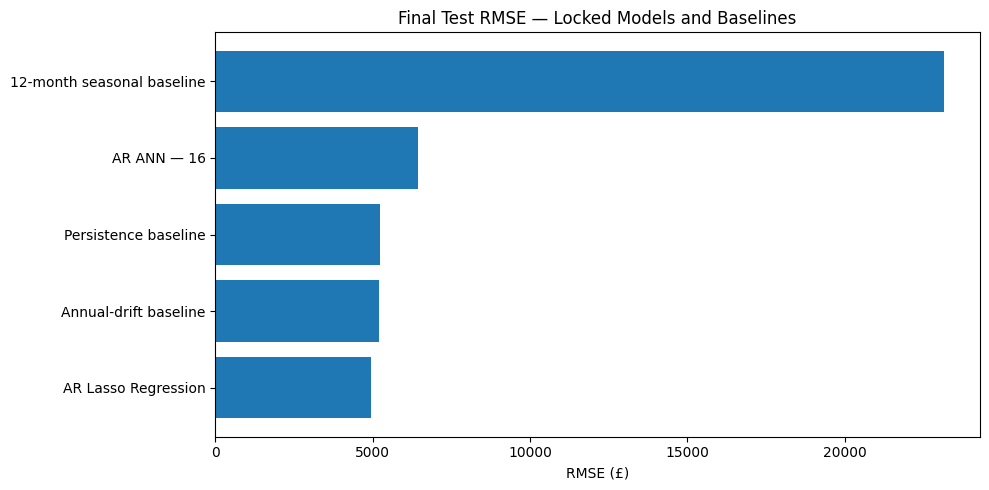

In [6]:
plot_data = final_comparison.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_data["model"], plot_data["RMSE"])
plt.title("Final Test RMSE — Locked Models and Baselines")
plt.xlabel("RMSE (£)")
plt.tight_layout()
plt.show()

## 6. Final-model decision

The final portfolio model is selected on the basis of the locked chronological test results, not algorithm complexity.

The model is considered preferable if it:

- beats the simple persistence and drift baselines;
- maintains low absolute and percentage error;
- behaves reasonably across the full test period;
- remains interpretable and reproducible.

In [7]:
winner = final_comparison.iloc[0]

print("Lowest final-test RMSE:", winner["model"])
print(f"RMSE: £{winner['RMSE']:,.0f}")
print(f"MAE: £{winner['MAE']:,.0f}")
print(f"MAPE: {winner['MAPE_pct']:.2f}%")
print(f"R²: {winner['R2']:.3f}")

Lowest final-test RMSE: AR Lasso Regression
RMSE: £4,956
MAE: £3,255
MAPE: 1.21%
R²: 0.844


## 7. Actual versus predicted prices

The time plot helps identify whether the model systematically lags turning points or develops persistent under- or overprediction.

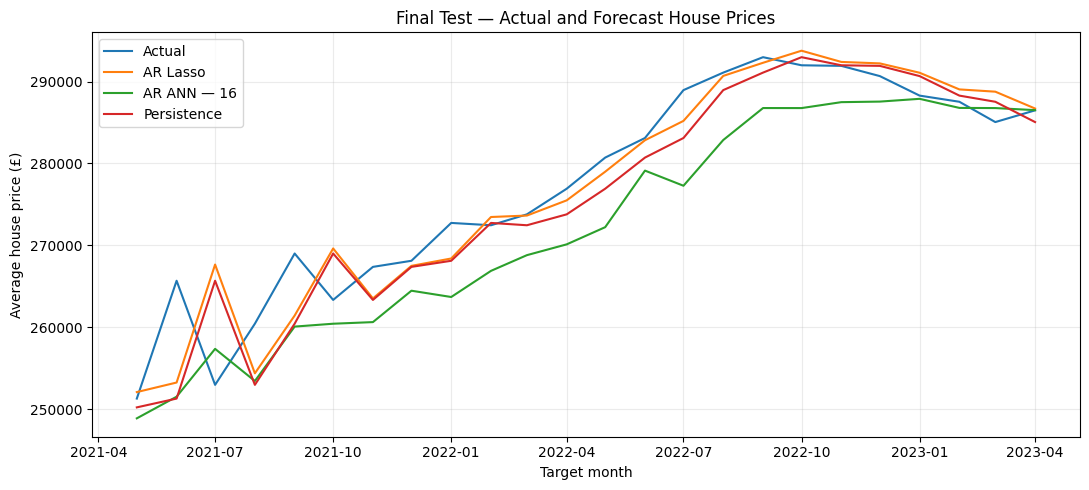

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(test["target_date"], test[TARGET], label="Actual")
plt.plot(test["target_date"], lasso_test_pred, label="AR Lasso")
plt.plot(test["target_date"], ann_test_pred, label="AR ANN — 16")
plt.plot(test["target_date"], persistence_pred, label="Persistence")
plt.title("Final Test — Actual and Forecast House Prices")
plt.xlabel("Target month")
plt.ylabel("Average house price (£)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Lasso residual diagnostics

Residuals are defined as **actual − predicted**.

Positive residuals indicate underprediction. Negative residuals indicate overprediction.

In [9]:
predictions = pd.DataFrame({
    "forecast_origin": test["forecast_origin"].to_numpy(),
    "target_date": test["target_date"].to_numpy(),
    "actual_gbp": test[TARGET].to_numpy(),
    "lasso_predicted_gbp": lasso_test_pred,
    "ann_predicted_gbp": ann_test_pred,
    "persistence_predicted_gbp": persistence_pred,
})

predictions["lasso_residual_gbp"] = (
    predictions["actual_gbp"]
    - predictions["lasso_predicted_gbp"]
)
predictions["lasso_absolute_error_gbp"] = (
    predictions["lasso_residual_gbp"].abs()
)
predictions["lasso_absolute_percentage_error"] = (
    predictions["lasso_absolute_error_gbp"]
    / predictions["actual_gbp"]
    * 100
)

predictions.head()

,forecast_origin,target_date,actual_gbp,lasso_predicted_gbp,ann_predicted_gbp,persistence_predicted_gbp,lasso_residual_gbp,lasso_absolute_error_gbp,lasso_absolute_percentage_error
0,2021-04-01,2021-05-01,"251,285.480","252,077.642","248,870.953","250,209.671",-792.161,792.161,0.315
1,2021-05-01,2021-06-01,"265,676.075","253,244.563","251,513.156","251,285.480","12,431.512","12,431.512",4.679
2,2021-06-01,2021-07-01,"252,960.133","267,655.404","257,357.219","265,676.075","-14,695.271","14,695.271",5.809
3,2021-07-01,2021-08-01,"260,429.179","254,369.901","253,429.875","252,960.133","6,059.278","6,059.278",2.327
4,2021-08-01,2021-09-01,"269,003.075","261,425.147","260,076.594","260,429.179","7,577.928","7,577.928",2.817


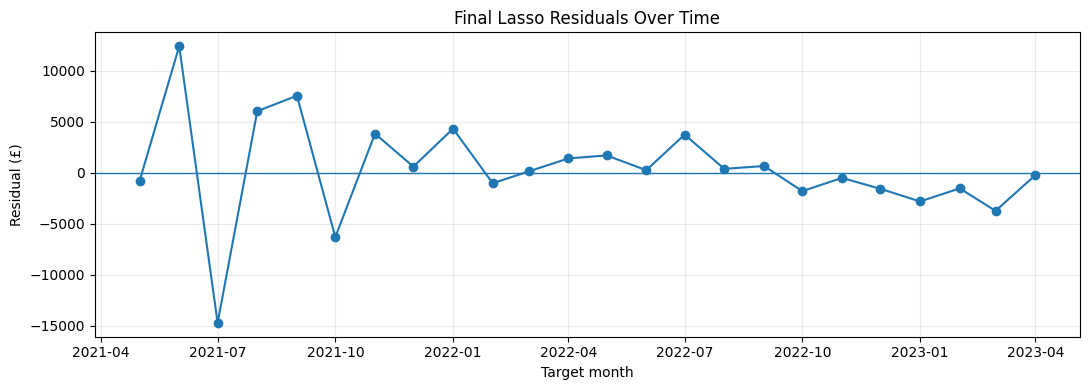

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(
    predictions["target_date"],
    predictions["lasso_residual_gbp"],
    marker="o",
)
plt.axhline(0, linewidth=1)
plt.title("Final Lasso Residuals Over Time")
plt.xlabel("Target month")
plt.ylabel("Residual (£)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

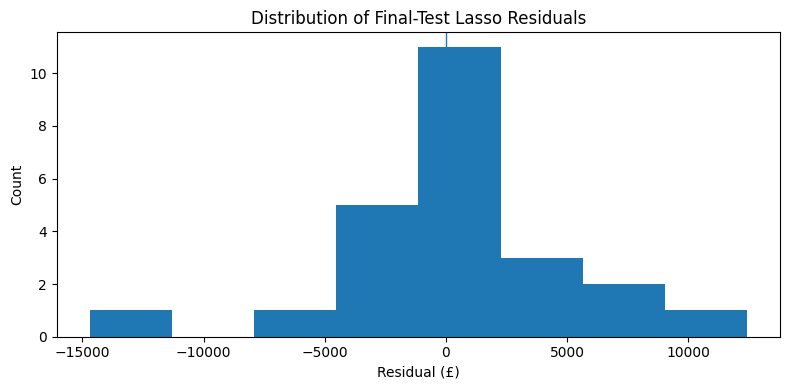

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(predictions["lasso_residual_gbp"], bins=8)
plt.axvline(0, linewidth=1)
plt.title("Distribution of Final-Test Lasso Residuals")
plt.xlabel("Residual (£)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
predictions.sort_values(
    "lasso_absolute_error_gbp",
    ascending=False,
).head(10)

,forecast_origin,target_date,actual_gbp,lasso_predicted_gbp,ann_predicted_gbp,persistence_predicted_gbp,lasso_residual_gbp,lasso_absolute_error_gbp,lasso_absolute_percentage_error
2,2021-06-01,2021-07-01,"252,960.133","267,655.404","257,357.219","265,676.075","-14,695.271","14,695.271",5.809
1,2021-05-01,2021-06-01,"265,676.075","253,244.563","251,513.156","251,285.480","12,431.512","12,431.512",4.679
4,2021-08-01,2021-09-01,"269,003.075","261,425.147","260,076.594","260,429.179","7,577.928","7,577.928",2.817
5,2021-09-01,2021-10-01,"263,333.230","269,620.002","260,427.219","269,003.075","-6,286.772","6,286.772",2.387
3,2021-07-01,2021-08-01,"260,429.179","254,369.901","253,429.875","252,960.133","6,059.278","6,059.278",2.327
8,2021-12-01,2022-01-01,"272,738.317","268,395.463","263,691.625","268,114.705","4,342.854","4,342.854",1.592
6,2021-10-01,2021-11-01,"267,369.958","263,518.173","260,625.156","263,333.230","3,851.785","3,851.785",1.441
14,2022-06-01,2022-07-01,"288,960.850","285,200.669","277,278.719","283,110.384","3,760.180","3,760.180",1.301
22,2023-02-01,2023-03-01,"285,056.727","288,769.142","286,766.219","287,536.751","-3,712.414","3,712.414",1.302
20,2022-12-01,2023-01-01,"288,288.610","291,080.654","287,895.562","290,671.803","-2,792.044","2,792.044",0.968


## 9. Error through the test period

The final test window spans different market conditions. Error is summarised by target year to check whether performance is concentrated in only one part of the holdout.

The 2021 and 2023 rows represent partial years because the test begins in May 2021 and ends in April 2023.

In [13]:
predictions["target_year"] = predictions["target_date"].dt.year

yearly_error = predictions.groupby("target_year").agg(
    observations=("target_date", "count"),
    MAE=("lasso_absolute_error_gbp", "mean"),
    MAPE_pct=("lasso_absolute_percentage_error", "mean"),
    mean_residual=("lasso_residual_gbp", "mean"),
)

yearly_error

,observations,MAE,MAPE_pct,mean_residual
target_year,,,,
2021,8,"6,539.467",2.501,"1,095.916"
2022,12,"1,464.630",0.518,661.552
2023,4,"2,058.931",0.718,"-2,058.931"


## 10. Approximate uncertainty in the final-test error metrics

The final test contains only 24 months, so a single MAE or RMSE value should not be treated as exact.

A **moving-block bootstrap** is used to estimate approximate 95% intervals while preserving short local sequences better than an independent-row bootstrap.

These intervals describe uncertainty in the observed test-window error, not a formal prediction interval for future house prices.

In [14]:
def moving_block_bootstrap_metrics(
    y_true,
    y_pred,
    block_length=3,
    n_bootstrap=2000,
    seed=SEED,
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    starts = np.arange(0, n - block_length + 1)

    mae_values = []
    rmse_values = []

    for _ in range(n_bootstrap):
        indices = []

        while len(indices) < n:
            start = rng.choice(starts)
            indices.extend(
                range(start, start + block_length)
            )

        indices = np.array(indices[:n])

        yt = y_true[indices]
        yp = y_pred[indices]

        mae_values.append(mean_absolute_error(yt, yp))
        rmse_values.append(
            mean_squared_error(yt, yp) ** 0.5
        )

    return {
        "MAE_lower_95": np.percentile(mae_values, 2.5),
        "MAE_upper_95": np.percentile(mae_values, 97.5),
        "RMSE_lower_95": np.percentile(rmse_values, 2.5),
        "RMSE_upper_95": np.percentile(rmse_values, 97.5),
    }


uncertainty = moving_block_bootstrap_metrics(
    test[TARGET],
    lasso_test_pred,
)

pd.DataFrame([uncertainty])

,MAE_lower_95,MAE_upper_95,RMSE_lower_95,RMSE_upper_95
0,"1,501.618","5,671.072","1,930.779","7,473.557"


## 11. Standardised Lasso coefficients

Because the Lasso pipeline standardises the inputs first, coefficient magnitudes can be compared across features.

A zero coefficient indicates that Lasso removed that feature from the fitted linear equation.

In [15]:
scaler = final_lasso.named_steps["scale"]
lasso_estimator = final_lasso.named_steps["model"]

coefficient_table = pd.DataFrame({
    "feature": AUTOREGRESSIVE_FEATURES,
    "standardised_coefficient_gbp": lasso_estimator.coef_,
})

coefficient_table["absolute_coefficient_gbp"] = (
    coefficient_table["standardised_coefficient_gbp"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "absolute_coefficient_gbp",
    ascending=False,
)

coefficient_table

,feature,standardised_coefficient_gbp,absolute_coefficient_gbp
0,house_price_lag_1m_gbp,"27,634.833","27,634.833"
6,target_month_cos,-686.002,686.002
2,house_price_lag_12m_gbp,-201.846,201.846
5,target_month_sin,41.840,41.840
1,house_price_lag_3m_gbp,-0.000,0.000
4,house_price_rolling_12m_mean_gbp,-0.000,0.000
3,house_price_rolling_3m_mean_gbp,0.000,0.000


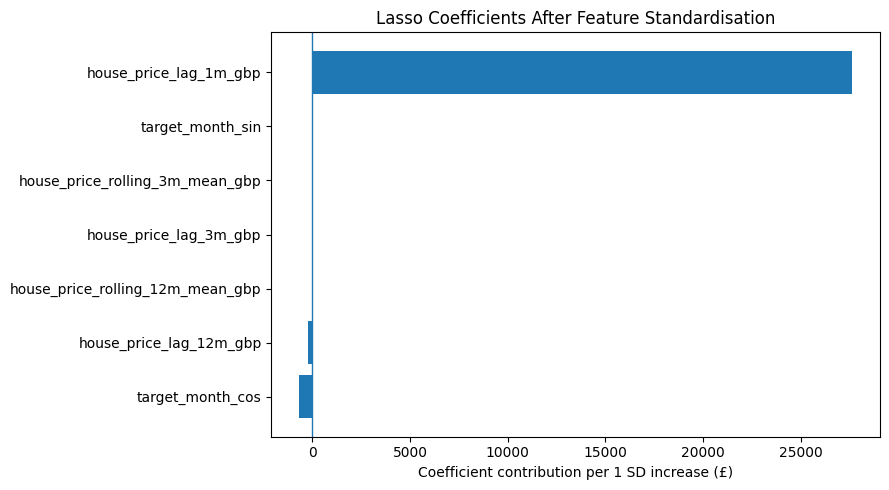

In [16]:
coef_plot = coefficient_table.sort_values(
    "standardised_coefficient_gbp"
)

plt.figure(figsize=(9, 5))
plt.barh(
    coef_plot["feature"],
    coef_plot["standardised_coefficient_gbp"],
)
plt.axvline(0, linewidth=1)
plt.title("Lasso Coefficients After Feature Standardisation")
plt.xlabel("Coefficient contribution per 1 SD increase (£)")
plt.tight_layout()
plt.show()

## 12. SHAP global explainability

SHAP values are calculated for the fitted Lasso estimator on the **standardised feature space**.

Because the Lasso output is in pounds, the resulting SHAP contributions are also expressed in pounds. The global importance below is the mean absolute SHAP contribution across the 24 final-test forecasts.

SHAP explains how the fitted model generates its predictions; it does not establish causal effects.

In [17]:
X_dev_scaled = scaler.transform(
    development[AUTOREGRESSIVE_FEATURES]
)
X_test_scaled = scaler.transform(
    test[AUTOREGRESSIVE_FEATURES]
)

explainer = shap.LinearExplainer(
    lasso_estimator,
    X_dev_scaled,
)

shap_values = explainer(
    X_test_scaled
)

shap_importance = pd.DataFrame({
    "feature": AUTOREGRESSIVE_FEATURES,
    "mean_absolute_shap_gbp": np.abs(
        shap_values.values
    ).mean(axis=0),
}).sort_values(
    "mean_absolute_shap_gbp",
    ascending=False,
)

shap_importance

,feature,mean_absolute_shap_gbp
0,house_price_lag_1m_gbp,"77,445.953"
6,target_month_cos,607.201
2,house_price_lag_12m_gbp,481.367
5,target_month_sin,37.272
1,house_price_lag_3m_gbp,0.000
4,house_price_rolling_12m_mean_gbp,0.000
3,house_price_rolling_3m_mean_gbp,0.000


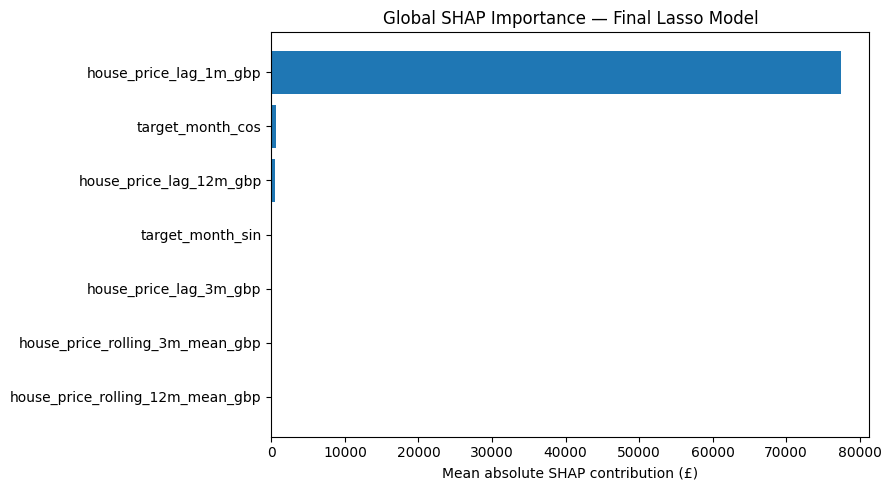

In [18]:
shap_plot = shap_importance.sort_values(
    "mean_absolute_shap_gbp"
)

plt.figure(figsize=(9, 5))
plt.barh(
    shap_plot["feature"],
    shap_plot["mean_absolute_shap_gbp"],
)
plt.title("Global SHAP Importance — Final Lasso Model")
plt.xlabel("Mean absolute SHAP contribution (£)")
plt.tight_layout()
plt.show()

## 13. Local explanation of the most difficult final-test forecast

The month with the largest absolute Lasso error is examined in detail.

The SHAP decomposition shows which features moved the fitted model's prediction above or below its expected prediction for that observation.

In [19]:
hardest_idx = int(
    np.argmax(
        np.abs(
            test[TARGET].to_numpy()
            - lasso_test_pred
        )
    )
)

hardest_date = test.iloc[hardest_idx]["target_date"]
hardest_actual = test.iloc[hardest_idx][TARGET]
hardest_pred = lasso_test_pred[hardest_idx]

print("Target month:", hardest_date.date())
print(f"Actual price: £{hardest_actual:,.0f}")
print(f"Predicted price: £{hardest_pred:,.0f}")
print(f"Absolute error: £{abs(hardest_actual - hardest_pred):,.0f}")

Target month: 2021-07-01
Actual price: £252,960
Predicted price: £267,655
Absolute error: £14,695


In [20]:
local_explanation = pd.DataFrame({
    "feature": AUTOREGRESSIVE_FEATURES,
    "feature_value": test.iloc[hardest_idx][
        AUTOREGRESSIVE_FEATURES
    ].to_numpy(dtype=float),
    "shap_contribution_gbp": shap_values.values[hardest_idx],
})

local_explanation["absolute_contribution_gbp"] = (
    local_explanation["shap_contribution_gbp"].abs()
)

local_explanation = local_explanation.sort_values(
    "absolute_contribution_gbp",
    ascending=False,
)

local_explanation

,feature,feature_value,shap_contribution_gbp,absolute_contribution_gbp
0,house_price_lag_1m_gbp,"265,676.075","67,293.408","67,293.408"
6,target_month_cos,-0.866,842.620,842.620
2,house_price_lag_12m_gbp,"236,686.929",-339.923,339.923
5,target_month_sin,-0.500,-33.325,33.325
1,house_price_lag_3m_gbp,"250,209.671",-0.000,0.000
4,house_price_rolling_12m_mean_gbp,"247,900.193",-0.000,0.000
3,house_price_rolling_3m_mean_gbp,"255,723.742",0.000,0.000


In [21]:
base_value = float(np.asarray(shap_values.base_values[hardest_idx]).reshape(-1)[0])
shap_sum = float(shap_values.values[hardest_idx].sum())

print(f"SHAP expected value: £{base_value:,.0f}")
print(f"Sum of SHAP contributions: £{shap_sum:,.0f}")
print(f"Reconstructed prediction: £{base_value + shap_sum:,.0f}")
print(f"Pipeline prediction: £{hardest_pred:,.0f}")

SHAP expected value: £199,893
Sum of SHAP contributions: £67,763
Reconstructed prediction: £267,655
Pipeline prediction: £267,655


## 14. Responsible-modelling assessment

### Intended use

This model is a **portfolio forecasting experiment** for national-level UK average house prices. It demonstrates a reproducible machine-learning workflow and is not intended to make individual mortgage, lending, valuation or investment decisions.

### Important limitations

- The modelling sample contains only 160 monthly forecasting observations.
- The target is a national average, so regional and property-level variation is not represented.
- House-price history dominates the one-month forecast; this is not evidence that macroeconomic variables are unimportant to the housing market.
- Official statistical series may be revised after initial publication.
- The reconstruction uses values aligned by reference month. A production system would need to model the **actual publication/release lag** of every source to ensure each value was truly available on the forecast date.
- The original project used mortgage-product rates. The reconstruction does not fabricate incomplete historical mortgage-rate series and instead uses official Bank Rate as a reproducible interest-rate indicator in the broader dataset.
- Unusual economic shocks are retained rather than removed as outliers, but future regimes may differ materially from the historical sample.
- SHAP and coefficient explanations describe the model's mathematical behaviour, not causal relationships.

### Human oversight

Any real-world use should combine model output with current market information, domain expertise, data-quality checks and explicit uncertainty. The forecast should not be treated as an automated decision rule.

## 15. Export reproducible evaluation artefacts

The final test predictions, model-comparison table and SHAP global-importance table are exported to the repository's `results/` directory.

In [22]:
predictions.to_csv(
    RESULTS_DIR / "final_test_predictions.csv",
    index=False,
)

final_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False,
)

shap_importance.to_csv(
    RESULTS_DIR / "shap_global_importance.csv",
    index=False,
)

coefficient_table.to_csv(
    RESULTS_DIR / "lasso_coefficients.csv",
    index=False,
)

print("Exported:")
for filename in [
    "final_test_predictions.csv",
    "final_model_comparison.csv",
    "shap_global_importance.csv",
    "lasso_coefficients.csv",
]:
    print(" -", RESULTS_DIR / filename)

Exported:
 - /mnt/data/evaluation_project/results/final_test_predictions.csv
 - /mnt/data/evaluation_project/results/final_model_comparison.csv
 - /mnt/data/evaluation_project/results/shap_global_importance.csv
 - /mnt/data/evaluation_project/results/lasso_coefficients.csv


## 16. Final project conclusion

The reconstructed project reaches a different and more rigorous conclusion than simply choosing the most sophisticated algorithm.

**Autoregressive Lasso Regression is the final selected forecasting model.**

On the untouched May 2021–April 2023 test period it outperforms the ANN and the simple persistence and drift baselines. The result supports several broader lessons:

- chronological evaluation can change the apparent ranking of models;
- recent price history is highly informative for one-month-ahead national house-price forecasting;
- additional macroeconomic predictors do not automatically improve a short-horizon forecast;
- tree ensembles and neural networks can underperform simpler regularised regression on small, trending tabular datasets;
- explainability and explicit limitations are part of model quality, not optional additions;
- a strong analytical project should report negative results and uncertainty rather than optimise the narrative around a preferred algorithm.

This portfolio reconstruction therefore demonstrates the complete workflow from data provenance and leakage-aware preparation through EDA, classical modelling, deep learning, final evaluation, explainability and responsible model documentation.